# TRAS - C70 Quenched

### Mounting the google drive

In [1]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np
import pandas as pd

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from math import pi

In [2]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Mounted at /content/drive


In [3]:
# # A good test to do is if you can see the contents of the directory in which you work on your google drive.
# # Here "My Drive" refers to the "root" of your google drive.
# # By default your notebook should be in a directory called Colab Notebooks.
# # This template assumes all files you want to read in are copied in the
# # same directory. Note the slash at the end of the first line.

# #==============================================================================================================
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/Crab_pulsar_template/' # Fin's Directory
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/CrabPulsar/Crab_pulsar_template' #Fin's 2
pathTRAS = rootpathdrive+'/'+'My Drive/Colab Notebooks/TRAS/Pulse_width_experiments/BZC05 probemaxx pump change' #Sara's directory
# #==============================================================================================================

filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathTRAS):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.


['pump 0 probemaxx 6 2026-03-10 12-40-36 TA.csv', 'pump 0 probemaxx 6 2026-03-10 12-40-36 TA.xml', 'pump 1 probemaxx 6 2026-03-10 12-44-00 TA.csv', 'pump 1 probemaxx 6 2026-03-10 12-44-00 TA.xml', 'pump 2 probemaxx 6 2026-03-10 12-46-21 TA.csv', 'pump 2 probemaxx 6 2026-03-10 12-46-21 TA.xml', 'pump 3 probemaxx 6 2026-03-10 12-48-39 TA.csv', 'pump 3 probemaxx 6 2026-03-10 12-48-39 TA.xml', 'pump 4 probemaxx 6 2026-03-10 12-50-43 TA.xml', 'pump 4 probemaxx 6 2026-03-10 12-50-43 TA.csv', 'pump 5 probemaxx 6 2026-03-10 12-52-41 TA.xml', 'pump 5 probemaxx 6 2026-03-10 12-52-41 TA.csv', 'pump 6 probemaxx 6 2026-03-10 12-56-14 TA.csv', 'pump 6 probemaxx 6 2026-03-10 12-56-14 TA.xml', 'pump 7 probemaxx 6 2026-03-10 12-59-07 TA.xml', 'pump 7 probemaxx 6 2026-03-10 12-59-07 TA.csv', 'pump 8 probemaxx 6 2026-03-10 15-14-55 TA.xml', 'pump 8 probemaxx 6 2026-03-10 15-14-55 TA.csv', 'pump 9 probemaxx 6 2026-03-10 15-17-11 TA.xml', 'pump 9 probemaxx 6 2026-03-10 15-17-11 TA.csv', 'pump 10 probemaxx 

## Part 5 - Pulse width using ZnTPP samples

**Keeping concentration and repetition rate constant, investigate the effect of varying the
pulse width of the pump and probe lasers on the structure of the TA curve.
Plotted length of spike against increment**

Slope:     0.5931 ± 0.0295
Intercept: -0.2441 ± 0.3020
Chi²:          78.2881
DOF:           14
Reduced Chi²:  5.5920


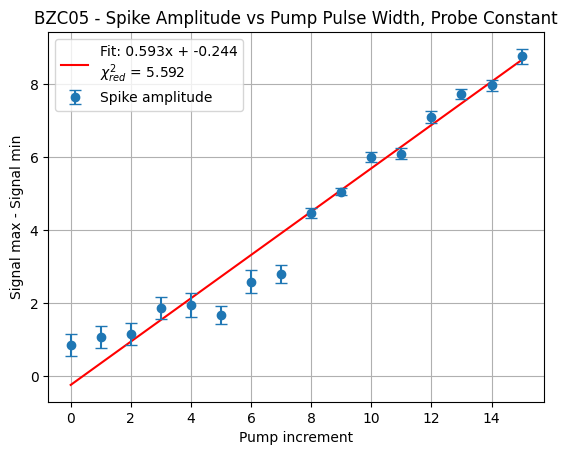

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

signal_max_array = []
signal_min_array = []
increment_array  = []
spike_array      = []
error            = []

for file in filelist:
    if not file.endswith(".csv"):
        continue
    if "TA" not in file:
        continue

    csv_title = file

    match = re.search(r"pump\s*(\d+)", csv_title)
    if not match:
        print(f"Skipping bad filename: {csv_title}")
        continue

    increment = int(match.group(1))

    df = pd.read_csv(
        os.path.join(pathTRAS, csv_title),
        sep=";",
        header=None,
        names=["time", "signal"]
    )

    df = df.iloc[1:].reset_index(drop=True)
    df = df.astype(float)
    signal = df["signal"].to_numpy()

    df_bg     = df[df["time"] < -10]
    bg_signal = df_bg["signal"].to_numpy()

    signal_min   = np.mean(bg_signal)
    signal_max   = np.max(signal)
    signal_error = np.std(bg_signal)          # Fixed: was np.stdev

    error.append(signal_error)
    signal_max_array.append(signal_max)
    signal_min_array.append(signal_min)

    spike_length = signal_max - signal_min
    spike_array.append(spike_length)
    increment_array.append(increment)

if len(increment_array) == 0:
    raise ValueError("No valid files processed — check filename pattern.")

# ── Sort (all three arrays together) ──────────────────────────────────────────
data = sorted(zip(increment_array, spike_array, error))  # Fixed: error now sorted too
increment_array, spike_array, error = zip(*data)

increment_array = np.array(increment_array, dtype=float)
spike_array     = np.array(spike_array,     dtype=float)
error           = np.array(error,           dtype=float)

# ── Weighted linear fit ────────────────────────────────────────────────────────
weights       = 1 / error
coeff, cov    = np.polyfit(increment_array, spike_array, 1, w=weights, cov=True)
slope         = coeff[0]
intercept     = coeff[1]
slope_err     = np.sqrt(cov[0, 0])
intercept_err = np.sqrt(cov[1, 1])

print(f"Slope:     {slope:.4f} ± {slope_err:.4f}")
print(f"Intercept: {intercept:.4f} ± {intercept_err:.4f}")

# ── Chi-squared ────────────────────────────────────────────────────────────────
y_pred    = slope * increment_array + intercept
residuals = spike_array - y_pred
chi2      = np.sum((residuals / error) ** 2)
dof       = len(spike_array) - 2          # 2 free parameters (slope, intercept)
chi2_red  = chi2 / dof

print(f"Chi²:          {chi2:.4f}")
print(f"DOF:           {dof}")
print(f"Reduced Chi²:  {chi2_red:.4f}")

# ── Plot ───────────────────────────────────────────────────────────────────────
x_fit = np.linspace(increment_array.min(), increment_array.max(), 200)
y_fit = slope * x_fit + intercept

plt.errorbar(increment_array, spike_array, yerr=error,        # errorbars
             fmt='o', capsize=4, label="Spike amplitude", zorder=3)
plt.plot(x_fit, y_fit, 'r-',
         label=f"Fit: {slope:.3f}x + {intercept:.3f}\n$\\chi^2_{{red}}$ = {chi2_red:.3f}")

plt.xlabel("Pump increment")
plt.ylabel("Signal max - Signal min")
plt.title("BZC05 - Spike Amplitude vs Pump Pulse Width, Probe Constant")
plt.legend()
plt.grid(True)
plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/TRAS/Pulse_width_experiments/BZC05_ProbeMaxx_PumpChange.png",
    dpi=300, bbox_inches="tight"
)
plt.show()


Processing increment 0:
  Pump FWHM = 6.00 ns -> σ = 2.55 ns
  Probe FWHM = 22.0 ns -> σ = 9.34 ns
  Total σ_IRF = 9.68 ns
  Measurement error (σ_noise) = 3.0124e-01
  Initial guesses: A=0.8541, τ=4209.11 ns, t0=3210.00 ns

  ✅ Fit successful!
  Fitted parameters:
    A  = 1.2009 ± 2.4737
    τ  = 10.00 ± 24.42 ns
    t0 = 3202.11 ± 16.40 ns

  Goodness of fit:
    χ² = 476.82
    χ²_red = 0.9205 (ideal: ~1)
    p-value = 0.9022 (ideal: 0.05-0.95)
    R² = 0.003349


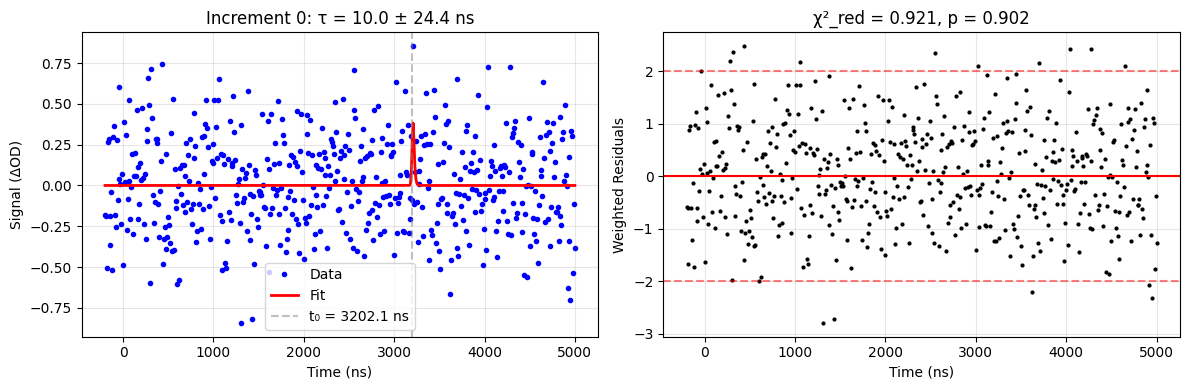


Processing increment 1:
  Pump FWHM = 14.20 ns -> σ = 6.03 ns
  Probe FWHM = 22.0 ns -> σ = 9.34 ns
  Total σ_IRF = 11.12 ns
  Measurement error (σ_noise) = 3.5557e-01
  Initial guesses: A=1.0716, τ=4624.06 ns, t0=1770.00 ns

  ✅ Fit successful!
  Fitted parameters:
    A  = 0.1539 ± 0.0500
    τ  = 3110.75 ± 2226.95 ns
    t0 = 1667.33 ± 46.30 ns

  Goodness of fit:
    χ² = 450.96
    χ²_red = 0.8706 (ideal: ~1)
    p-value = 0.9846 (ideal: 0.05-0.95)
    R² = -0.139300


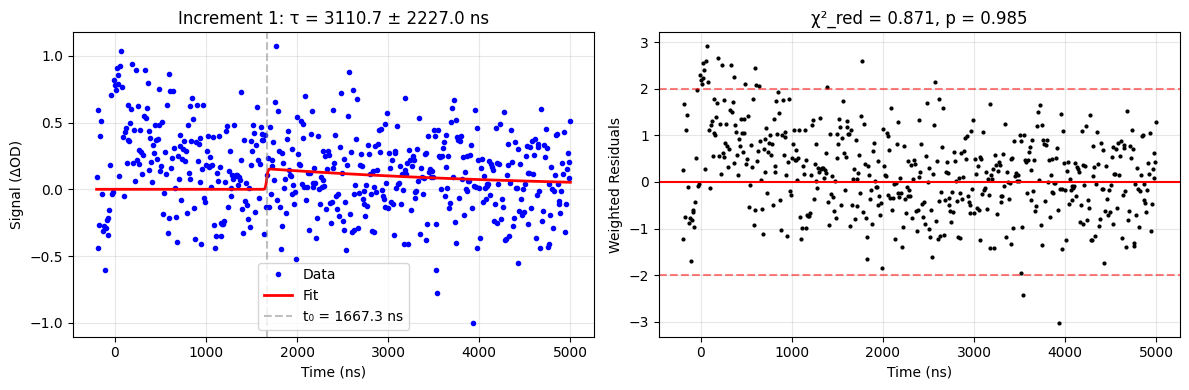


Processing increment 10:
  Pump FWHM = 88.00 ns -> σ = 37.37 ns
  Probe FWHM = 22.0 ns -> σ = 9.34 ns
  Total σ_IRF = 38.52 ns
  Measurement error (σ_noise) = 1.4026e-01
  Initial guesses: A=5.9995, τ=2587.11 ns, t0=90.00 ns

  ✅ Fit successful!
  Fitted parameters:
    A  = 5.5287 ± 0.0303
    τ  = 975.61 ± 7.52 ns
    t0 = 20.57 ± 1.00 ns

  Goodness of fit:
    χ² = 3598.25
    χ²_red = 6.9464 (ideal: ~1)
    p-value = 0.0000 (ideal: 0.05-0.95)
    R² = 0.906183

Processing increment 11:
  Pump FWHM = 96.20 ns -> σ = 40.85 ns
  Probe FWHM = 22.0 ns -> σ = 9.34 ns
  Total σ_IRF = 41.90 ns
  Measurement error (σ_noise) = 1.4823e-01
  Initial guesses: A=6.0958, τ=2841.36 ns, t0=90.00 ns

  ✅ Fit successful!
  Fitted parameters:
    A  = 5.7179 ± 0.0308
    τ  = 1054.15 ± 8.00 ns
    t0 = 23.71 ± 1.07 ns

  Goodness of fit:
    χ² = 4274.27
    χ²_red = 8.2515 (ideal: ~1)
    p-value = 0.0000 (ideal: 0.05-0.95)
    R² = 0.886813

Processing increment 12:
  Pump FWHM = 104.40 ns -> σ = 

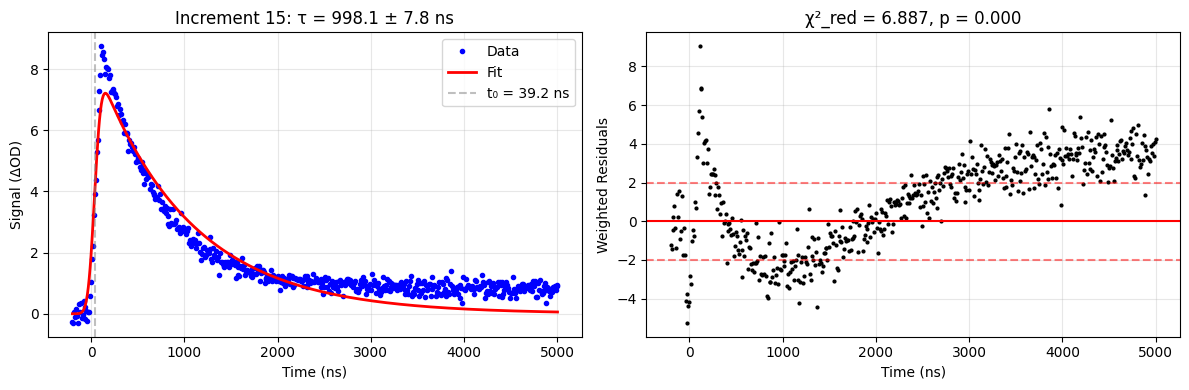


Processing increment 2:
  Pump FWHM = 22.40 ns -> σ = 9.51 ns
  Probe FWHM = 22.0 ns -> σ = 9.34 ns
  Total σ_IRF = 13.33 ns
  Measurement error (σ_noise) = 3.1508e-01
  Initial guesses: A=1.1458, τ=1574.20 ns, t0=470.00 ns

  ✅ Fit successful!
  Fitted parameters:
    A  = 0.7810 ± 0.0892
    τ  = 539.71 ± 86.88 ns
    t0 = -18.26 ± 9.16 ns

  Goodness of fit:
    χ² = 429.77
    χ²_red = 0.8297 (ideal: ~1)
    p-value = 0.9981 (ideal: 0.05-0.95)
    R² = 0.207138

Processing increment 3:
  Pump FWHM = 30.60 ns -> σ = 12.99 ns
  Probe FWHM = 22.0 ns -> σ = 9.34 ns
  Total σ_IRF = 16.00 ns
  Measurement error (σ_noise) = 3.0295e-01
  Initial guesses: A=1.8619, τ=510.99 ns, t0=60.00 ns

  ✅ Fit successful!
  Fitted parameters:
    A  = 1.0224 ± 0.0638
    τ  = 953.28 ± 83.98 ns
    t0 = 1.81 ± 7.27 ns

  Goodness of fit:
    χ² = 562.81
    χ²_red = 1.0865 (ideal: ~1)
    p-value = 0.0846 (ideal: 0.05-0.95)
    R² = 0.344106

Processing increment 4:
  Pump FWHM = 38.80 ns -> σ = 16.48 

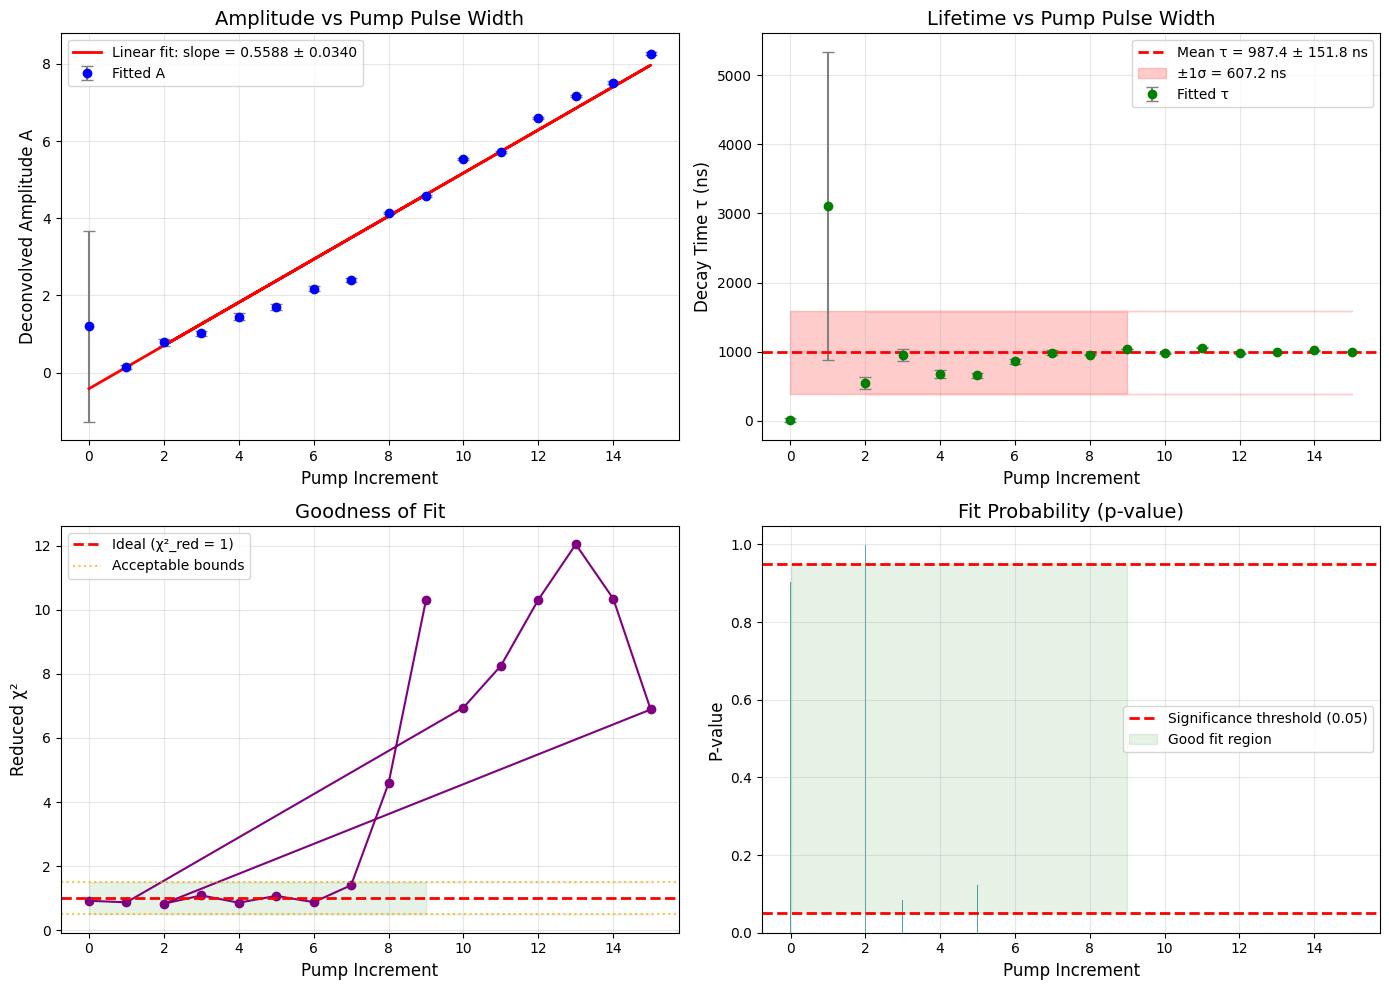


QUALITY ASSESSMENT
⚠️  Warning: χ²_red > 1.5 - Underestimated measurement errors or poor model
⚠️  Warning: Lifetime shows significant variation across pump widths

Final Lifetime Result: τ = 988.8 ± 2.5 ns
(Weighted average of 16 measurements)


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit
from scipy.special import erfc
from scipy import stats

# ── Constants and Parameters ─────────────────────────────────────────────────────────────
NS_PER_INCREMENT = (129 - 6) / 15   # ~8.2 ns per pump increment (FWHM)
FWHM_TO_SIGMA = 1 / 2.355           # Conversion factor: sigma = FWHM / 2.355

# Laser pulse parameters (all in FWHM, ns)
BASE_PUMP_FWHM = 6.0                # Base pump pulse width at increment 0 (ns)
PROBE_FWHM = 22.0                   # Probe pulse width FWHM (ns)

def analytical_model(t, A, tau, t0, sigma_irf):
    """
    Exponentially Modified Gaussian (EMG) for kinetics.
    Exact analytical solution for exponential decay convolved with Gaussian IRF.

    Parameters:
    -----------
    t : array_like
        Time points (ns)
    A : float
        Amplitude (initial excited state population)
    tau : float
        Decay time constant (ns)
    t0 : float
        Time zero (ns)
    sigma_irf : float
        IRF standard deviation (ns, NOT FWHM!)

    Returns:
    --------
    array_like : Convolved signal
    """
    # Numerical safeguards
    tau = max(tau, 1e-6)        # Prevent division by zero
    sigma_irf = max(sigma_irf, 1e-6)

    # Pre-compute constants for efficiency
    sigma2 = sigma_irf ** 2
    tau2 = tau ** 2

    # EMG formula
    term1 = sigma2 / (2 * tau2) - (t - t0) / tau
    arg = (sigma2 / tau - (t - t0)) / (np.sqrt(2) * sigma_irf)

    return (A / 2) * np.exp(term1) * erfc(arg)

def calculate_chi_square(y_obs, y_pred, y_err, n_params):
    """
    Calculate reduced chi-square statistic for goodness of fit.

    Parameters:
    -----------
    y_obs : array_like
        Observed data
    y_pred : array_like
        Predicted/fitted data
    y_err : array_like
        Measurement errors (standard deviations)
    n_params : int
        Number of fitted parameters (A, tau, t0 = 3)

    Returns:
    --------
    chi_sq : float
        Chi-square value
    chi_sq_red : float
        Reduced chi-square (should be ~1 for good fit)
    p_value : float
        P-value for goodness of fit (0.05-0.95 typically good)
    """
    residuals = y_obs - y_pred
    chi_sq = np.sum((residuals / y_err) ** 2)
    dof = len(y_obs) - n_params
    chi_sq_red = chi_sq / dof if dof > 0 else np.inf

    # Calculate p-value from chi-square distribution
    p_value = 1 - stats.chi2.cdf(chi_sq, dof) if dof > 0 else 0

    return chi_sq, chi_sq_red, p_value

def estimate_measurement_error(signal, window_size=5):
    """
    Estimate measurement error from the pre-trigger baseline noise.

    Parameters:
    -----------
    signal : array_like
        Signal trace
    window_size : int
        Number of points to use for noise estimation

    Returns:
    --------
    noise_std : float
        Estimated standard deviation of measurement noise
    """
    # Use the first 'window_size' points (pre-trigger) to estimate noise
    noise_region = signal[:min(window_size, len(signal))]
    return max(np.std(noise_region), 1e-6)  # Prevent zero error

def get_initial_guesses(t, signal, sigma_irf):
    """
    Generate intelligent initial guesses for EMG fitting.

    Parameters:
    -----------
    t : array_like
        Time points
    signal : array_like
        Signal values
    sigma_irf : float
        IRF standard deviation

    Returns:
    --------
    tuple : (A_guess, tau_guess, t0_guess)
    """
    # Find peak position
    peak_idx = np.argmax(signal)
    t0_guess = t[peak_idx]

    # Amplitude guess: observed peak * approximate correction factor
    # For tau >> sigma, correction factor ~ exp(sigma²/(2τ²))
    tau_guess_initial = 1000.0  # Based on prior knowledge (~1009 ns)
    correction = np.exp(sigma_irf**2 / (2 * tau_guess_initial**2))
    A_guess = signal[peak_idx] * correction

    # Estimate tau from the tail (after ~3 sigma from peak)
    tail_start_idx = np.searchsorted(t, t0_guess + 3 * sigma_irf)
    if tail_start_idx < len(t) and tail_start_idx + 5 < len(t):
        tail_t = t[tail_start_idx:]
        tail_signal = signal[tail_start_idx:]

        # Fit exponential to tail in log space
        log_signal = np.log(np.maximum(tail_signal, 1e-10))
        if len(tail_t) > 3:
            # Linear fit: log(y) = log(A) - t/tau
            coeffs = np.polyfit(tail_t - tail_t[0], log_signal, 1)
            tau_guess = -1 / coeffs[0] if coeffs[0] < 0 else tau_guess_initial
        else:
            tau_guess = tau_guess_initial
    else:
        tau_guess = tau_guess_initial

    return A_guess, tau_guess, t0_guess

# ── Main Processing Loop ─────────────────────────────────────────────────────────────────
increment_array = []
A_array = []
tau_array = []
A_err_array = []
tau_err_array = []
chi_sq_red_array = []
p_value_array = []

# Assuming 'filelist' and 'pathTRAS' are defined in your environment
for file in sorted(filelist):
    if not (file.endswith(".csv") and "TA" in file):
        continue

    # Extract pump increment from filename
    match = re.search(r"pump\s*(\d+)", file, re.IGNORECASE)
    if not match:
        print(f"Skipping {file}: cannot parse pump increment")
        continue

    increment = int(match.group(1))

    # Read data
    df = pd.read_csv(
        os.path.join(pathTRAS, file),
        sep=";",
        header=None,
        names=["time", "signal"]
    )
    df = df.iloc[1:].reset_index(drop=True).astype(float)

    # Background subtraction using pre-trigger region (t < -10 ns)
    bg_mask = df["time"] < -10
    if bg_mask.sum() > 0:
        bg_mean = df[bg_mask]["signal"].mean()
    else:
        bg_mean = df["signal"].iloc[:10].mean()

    # Correct signal and keep region of interest (include some pre-trigger)
    df_spike = df[df["time"] >= -200].copy()
    df_spike["signal_corr"] = df_spike["signal"] - bg_mean

    time_data = df_spike["time"].to_numpy()
    signal_data = df_spike["signal_corr"].to_numpy()

    # Estimate measurement error from pre-trigger region
    pre_trigger_mask = time_data < -10
    if pre_trigger_mask.sum() > 5:
        measurement_error = np.std(signal_data[pre_trigger_mask])
    else:
        measurement_error = estimate_measurement_error(signal_data)
    measurement_error = max(measurement_error, 1e-6)

    # Calculate IRF width (convert FWHM to sigma)
    pump_fwhm = BASE_PUMP_FWHM + increment * NS_PER_INCREMENT
    pump_sigma = pump_fwhm * FWHM_TO_SIGMA
    probe_sigma = PROBE_FWHM * FWHM_TO_SIGMA
    sigma_irf = np.sqrt(pump_sigma**2 + probe_sigma**2)

    print(f"\n{'='*60}")
    print(f"Processing increment {increment}:")
    print(f"  Pump FWHM = {pump_fwhm:.2f} ns -> σ = {pump_sigma:.2f} ns")
    print(f"  Probe FWHM = {PROBE_FWHM:.1f} ns -> σ = {probe_sigma:.2f} ns")
    print(f"  Total σ_IRF = {sigma_irf:.2f} ns")
    print(f"  Measurement error (σ_noise) = {measurement_error:.4e}")

    # Define model with fixed sigma_irf
    def model_fixed_irf(t, A, tau, t0):
        return analytical_model(t, A, tau, t0, sigma_irf)

    # Get initial guesses
    A_guess, tau_guess, t0_guess = get_initial_guesses(time_data, signal_data, sigma_irf)
    print(f"  Initial guesses: A={A_guess:.4f}, τ={tau_guess:.2f} ns, t0={t0_guess:.2f} ns")

    try:
        # Perform fit with bounds
        popt, pcov = curve_fit(
            model_fixed_irf,
            time_data,
            signal_data,
            p0=[A_guess, tau_guess, t0_guess],
            bounds=([0, 10, time_data[0]], [np.inf, 5000, time_data[-1]]),
            maxfev=10000,
            sigma=measurement_error * np.ones_like(signal_data),
            absolute_sigma=True
        )

        # Calculate parameter errors
        perr = np.sqrt(np.diag(pcov))
        A_fit, tau_fit, t0_fit = popt
        A_err, tau_err, t0_err = perr

        # Calculate fit and chi-square statistics
        fitted_signal = model_fixed_irf(time_data, A_fit, tau_fit, t0_fit)
        chi_sq, chi_sq_red, p_value = calculate_chi_square(
            signal_data, fitted_signal,
            measurement_error * np.ones_like(signal_data),
            n_params=3
        )

        # Calculate R-squared
        ss_res = np.sum((signal_data - fitted_signal)**2)
        ss_tot = np.sum((signal_data - np.mean(signal_data))**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

        # Print results
        print(f"\n  ✅ Fit successful!")
        print(f"  Fitted parameters:")
        print(f"    A  = {A_fit:.4f} ± {A_err:.4f}")
        print(f"    τ  = {tau_fit:.2f} ± {tau_err:.2f} ns")
        print(f"    t0 = {t0_fit:.2f} ± {t0_err:.2f} ns")
        print(f"\n  Goodness of fit:")
        print(f"    χ² = {chi_sq:.2f}")
        print(f"    χ²_red = {chi_sq_red:.4f} (ideal: ~1)")
        print(f"    p-value = {p_value:.4f} (ideal: 0.05-0.95)")
        print(f"    R² = {r_squared:.6f}")

        # Store results
        increment_array.append(increment)
        A_array.append(A_fit)
        tau_array.append(tau_fit)
        A_err_array.append(A_err)
        tau_err_array.append(tau_err)
        chi_sq_red_array.append(chi_sq_red)
        p_value_array.append(p_value)

        # Optional: Plot individual fit for inspection
        if abs(increment) <= 1 or increment == max([int(re.search(r"pump\s*(\d+)", f, re.IGNORECASE).group(1))
                                                     for f in filelist if re.search(r"pump\s*(\d+)", f)]):
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

            # Main fit plot
            ax1.plot(time_data, signal_data, 'bo', markersize=3, label='Data')
            ax1.plot(time_data, fitted_signal, 'r-', linewidth=2, label='Fit')
            ax1.axvline(t0_fit, color='gray', linestyle='--', alpha=0.5, label=f't₀ = {t0_fit:.1f} ns')
            ax1.set_xlabel('Time (ns)')
            ax1.set_ylabel('Signal (ΔOD)')
            ax1.set_title(f'Increment {increment}: τ = {tau_fit:.1f} ± {tau_err:.1f} ns')
            ax1.legend()
            ax1.grid(True, alpha=0.3)

            # Residuals plot
            residuals = signal_data - fitted_signal
            ax2.plot(time_data, residuals / measurement_error, 'ko', markersize=2)
            ax2.axhline(0, color='r', linestyle='-')
            ax2.axhline(2, color='r', linestyle='--', alpha=0.5)
            ax2.axhline(-2, color='r', linestyle='--', alpha=0.5)
            ax2.set_xlabel('Time (ns)')
            ax2.set_ylabel('Weighted Residuals')
            ax2.set_title(f'χ²_red = {chi_sq_red:.3f}, p = {p_value:.3f}')
            ax2.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

    except (RuntimeError, ValueError) as e:
        print(f"\n  ❌ Fit failed for increment {increment}: {e}")
        continue

# ── Convert to arrays for analysis ──────────────────────────────────────────────────────
increment_array = np.array(increment_array)
A_array = np.array(A_array)
tau_array = np.array(tau_array)
A_err_array = np.array(A_err_array)
tau_err_array = np.array(tau_err_array)
chi_sq_red_array = np.array(chi_sq_red_array)
p_value_array = np.array(p_value_array)

# ── Statistical Analysis of Results ─────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*60}")

# Amplitude analysis
coeff_A, cov_A = np.polyfit(increment_array, A_array, 1, cov=True)
slope_A = coeff_A[0]
intercept_A = coeff_A[1]
slope_A_err = np.sqrt(cov_A[0, 0])
intercept_A_err = np.sqrt(cov_A[1, 1])

# Lifetime analysis
tau_mean = np.mean(tau_array)
tau_std = np.std(tau_array)
tau_sem = tau_std / np.sqrt(len(tau_array))
tau_weighted_mean = np.average(tau_array, weights=1/tau_err_array**2)
tau_weighted_std = np.sqrt(1 / np.sum(1/tau_err_array**2))

# Chi-square statistics
mean_chi_sq_red = np.mean(chi_sq_red_array)
good_fits = np.sum((chi_sq_red_array > 0.5) & (chi_sq_red_array < 1.5))

print(f"\nAmplitude Analysis:")
print(f"  Slope: {slope_A:.4f} ± {slope_A_err:.4f}")
print(f"  Intercept: {intercept_A:.4f} ± {intercept_A_err:.4f}")

print(f"\nLifetime Analysis:")
print(f"  Mean τ: {tau_mean:.2f} ± {tau_sem:.2f} ns")
print(f"  Std Dev: {tau_std:.2f} ns")
print(f"  Weighted mean τ: {tau_weighted_mean:.2f} ± {tau_weighted_std:.2f} ns")
print(f"  Range: {tau_array.min():.2f} - {tau_array.max():.2f} ns")

print(f"\nGoodness of Fit Summary:")
print(f"  Mean χ²_red: {mean_chi_sq_red:.4f}")
print(f"  Good fits (0.5 < χ²_red < 1.5): {good_fits}/{len(chi_sq_red_array)} ({100*good_fits/len(chi_sq_red_array):.1f}%)")

# ── Create Final Publication-Quality Plot ───────────────────────────────────────────────
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Amplitude vs Pump Increment
ax1.errorbar(increment_array, A_array, yerr=A_err_array,
             fmt='o', capsize=4, markersize=6, color='blue',
             label='Fitted A', ecolor='gray')
ax1.plot(increment_array, np.polyval(coeff_A, increment_array),
         'r-', linewidth=2,
         label=f'Linear fit: slope = {slope_A:.4f} ± {slope_A_err:.4f}')
ax1.set_xlabel("Pump Increment", fontsize=12)
ax1.set_ylabel("Deconvolved Amplitude A", fontsize=12)
ax1.set_title("Amplitude vs Pump Pulse Width", fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Decay Time vs Pump Increment
ax2.errorbar(increment_array, tau_array, yerr=tau_err_array,
             fmt='o', capsize=4, markersize=6, color='green',
             label='Fitted τ', ecolor='gray')
ax2.axhline(tau_mean, color='red', linestyle='--', linewidth=2,
            label=f'Mean τ = {tau_mean:.1f} ± {tau_sem:.1f} ns')
ax2.fill_between(increment_array, tau_mean - tau_std, tau_mean + tau_std,
                  alpha=0.2, color='red', label=f'±1σ = {tau_std:.1f} ns')
ax2.set_xlabel("Pump Increment", fontsize=12)
ax2.set_ylabel("Decay Time τ (ns)", fontsize=12)
ax2.set_title("Lifetime vs Pump Pulse Width", fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Reduced Chi-Square Values
ax3.plot(increment_array, chi_sq_red_array, 'o-', color='purple', markersize=6)
ax3.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Ideal (χ²_red = 1)')
ax3.axhline(0.5, color='orange', linestyle=':', alpha=0.7, label='Acceptable bounds')
ax3.axhline(1.5, color='orange', linestyle=':', alpha=0.7)
ax3.fill_between(increment_array, 0.5, 1.5, alpha=0.1, color='green')
ax3.set_xlabel("Pump Increment", fontsize=12)
ax3.set_ylabel("Reduced χ²", fontsize=12)
ax3.set_title("Goodness of Fit", fontsize=14)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: P-values
ax4.bar(increment_array, p_value_array, width=0.015, color='teal', alpha=0.7)
ax4.axhline(0.05, color='red', linestyle='--', linewidth=2, label='Significance threshold (0.05)')
ax4.axhline(0.95, color='red', linestyle='--', linewidth=2)
ax4.fill_between(increment_array, 0.05, 0.95, alpha=0.1, color='green', label='Good fit region')
ax4.set_xlabel("Pump Increment", fontsize=12)
ax4.set_ylabel("P-value", fontsize=12)
ax4.set_title("Fit Probability (p-value)", fontsize=14)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("TRAS_Deconvolution_Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Summary Statistics Output ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("QUALITY ASSESSMENT")
print(f"{'='*60}")

if mean_chi_sq_red < 0.5:
    print("⚠️  Warning: χ²_red < 0.5 - Overestimated measurement errors or overfitting")
elif mean_chi_sq_red > 1.5:
    print("⚠️  Warning: χ²_red > 1.5 - Underestimated measurement errors or poor model")
else:
    print("✅ Good: χ²_red is in ideal range (0.5-1.5)")

if np.std(tau_array) / np.mean(tau_array) < 0.05:
    print("✅ Excellent: Lifetime is highly consistent across pump widths (<5% variation)")
elif np.std(tau_array) / np.mean(tau_array) < 0.10:
    print("✅ Good: Lifetime is consistent across pump widths (<10% variation)")
else:
    print("⚠️  Warning: Lifetime shows significant variation across pump widths")

print(f"\nFinal Lifetime Result: τ = {tau_weighted_mean:.1f} ± {tau_weighted_std:.1f} ns")
print(f"(Weighted average of {len(tau_array)} measurements)")